In [1]:
# 1. Install the core trio first to set the foundation
!pip install -q -U torch==2.5.1+cu121 torchvision==0.20.1+cu121 torchaudio==2.5.1+cu121 --index-url https://download.pytorch.org/whl/cu121

# 2. Install a version of xformers that is compatible with Torch 2.5.1
# Using 0.0.29 or higher usually solves the 2.4.1 restriction
!pip install -q xformers>=0.0.29 --index-url https://download.pytorch.org/whl/cu121

# 3. Install the rest, but use --no-deps for the 'sensitive' ones
# to prevent them from triggering another downgrade
!pip install -q diffusers transformers accelerate peft bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 80.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 46.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 43.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 35.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 67.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 15.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import argparse
import copy
import gc
import logging
import math
import os
import shutil
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import torch.utils.checkpoint
import transformers
from accelerate import Accelerator
from accelerate.logging import get_logger
from accelerate.utils import ProjectConfiguration, set_seed
from huggingface_hub.utils import insecure_hashlib
from packaging import version
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict, set_peft_model_state_dict
from PIL import Image
from PIL.ImageOps import exif_transpose
from torch.utils.data import Dataset
from torchvision import transforms
from tqdm.auto import tqdm
from transformers import AutoTokenizer, PretrainedConfig

import diffusers
from diffusers import (
    AutoencoderKL,
    DDPMScheduler,
    DiffusionPipeline,
    DPMSolverMultistepScheduler,
    StableDiffusionPipeline,
    UNet2DConditionModel,
)
from diffusers.loaders import LoraLoaderMixin
from diffusers.optimization import get_scheduler
from diffusers.training_utils import _set_state_dict_into_text_encoder, cast_training_params
from diffusers.utils import (
    check_min_version,
    convert_state_dict_to_diffusers,
    convert_unet_state_dict_to_peft,
    is_wandb_available,
)
from diffusers.utils.import_utils import is_xformers_available
from diffusers.utils.torch_utils import is_compiled_module

logger = get_logger(__name__)


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
class TrainingConfig:
    pretrained_model_name_or_path = "runwayml/stable-diffusion-v1-5"
    instance_data_dir = "./instance_data"
    class_data_dir = "./class_data"
    output_dir = "./lora-dreambooth-model"

    # STUDENT TODO: Update these prompts for your specific subject
    instance_prompt = "a photo of a fantasy book"   # Use a unique token like 'sks'
    class_prompt = "a photo of a book"          # Generic class prompt
    validation_prompt = "a photo of a fantasy book in a bucket"

    seed = 42
    resolution = 512
    center_crop = True
    train_text_encoder = True  # Enable to improve prompt fidelity
    train_batch_size = 1
    sample_batch_size = 4
    num_train_epochs = 10      # Increased for better convergence
    max_train_steps = 1000
    checkpointing_steps = 250
    gradient_accumulation_steps = 1
    learning_rate = 1e-4
    lr_scheduler = "constant"
    lr_warmup_steps = 0
    use_8bit_adam = True
    mixed_precision = "fp16"
    rank = 4
    with_prior_preservation = True
    prior_loss_weight = 1.0
    num_class_images = 100
    max_grad_norm = 1.0        # Gradient clipping

    # Validation settings
    num_validation_images = 4
    validation_epochs = 50
    validation_images = None

    # Misc
    logging_dir = "logs"
    report_to = "tensorboard"
    allow_tf32 = False
    local_rank = -1
    enable_xformers_memory_efficient_attention = True
    pre_compute_text_embeddings = False
    tokenizer_max_length = None
    text_encoder_use_attention_mask = False
    class_labels_conditioning = None

args = TrainingConfig()

if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
    args.mixed_precision = "no"
    print("CUDA not available. Switched mixed_precision to 'no'.")


In [4]:
import os
from pathlib import Path

if not os.path.exists(args.instance_data_dir):
    os.makedirs(args.instance_data_dir)
    print(f"Created directory {args.instance_data_dir}. Please upload your 5 images here.")

if not os.path.exists(args.class_data_dir):
    os.makedirs(args.class_data_dir)

# Helper function to display a grid of images
def image_grid(imgs, rows, cols):
    assert len(imgs) == rows*cols
    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    grid_w, grid_h = grid.size
    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid


Created directory ./instance_data. Please upload your 5 images here.


In [5]:
# BONUS: Class Image Generation (Prior Preservation)
# This cell generates generic class images (e.g., "a photo of a dog") if they are missing.
# They will be saved into args.class_data_dir.

import os
from pathlib import Path
import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
from tqdm.auto import tqdm

def generate_class_images(args, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    class_dir = Path(args.class_data_dir)
    class_dir.mkdir(parents=True, exist_ok=True)

    existing = []
    for ext in ("*.png", "*.jpg", "*.jpeg", "*.webp"):
        existing += list(class_dir.glob(ext))
    num_existing = len(existing)

    if num_existing >= args.num_class_images:
        print(f"Found {num_existing} class images. No need to generate more.")
        return

    num_to_gen = args.num_class_images - num_existing
    print(f"Generating {num_to_gen} class images to '{class_dir}' using prompt: {args.class_prompt!r}")

    torch_dtype = torch.float16 if (device == "cuda" and args.mixed_precision in ["fp16", "bf16"]) else torch.float32
    pipe = StableDiffusionPipeline.from_pretrained(
        args.pretrained_model_name_or_path,
        torch_dtype=torch_dtype,
        safety_checker=None, feature_extractor=None,
    )
    pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
    pipe = pipe.to(device)
    pipe.set_progress_bar_config(disable=True)

    generator = torch.Generator(device=device).manual_seed(args.seed)

    start_idx = num_existing
    for i in tqdm(range(num_to_gen), desc="Class image gen"):
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device == "cuda" and torch_dtype == torch.float16)):
            image = pipe(
                prompt=args.class_prompt,
                num_inference_steps=30,
                guidance_scale=7.5,
                generator=generator,
            ).images[0]

        out_path = class_dir / f"class_{start_idx + i:04d}.png"
        image.save(out_path)

    del pipe
    if device == "cuda":
        torch.cuda.empty_cache()
    print("Class image generation done.")

# Run if prior preservation enabled
if args.with_prior_preservation:
    generate_class_images(args)
else:
    print("Prior preservation is disabled; skipping class image generation.")


Generating 100 class images to 'class_data' using prompt: 'a photo of a book'


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

Class image gen:   0%|          | 0/100 [00:00<?, ?it/s]

Class image generation done.


In [6]:
def tokenize_prompt(tokenizer, prompt, tokenizer_max_length=None):
    if tokenizer_max_length is not None:
        max_length = tokenizer_max_length
    else:
        max_length = tokenizer.model_max_length

    text_inputs = tokenizer(
        prompt,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt",
    )

    return text_inputs


In [7]:
class DreamBoothDataset(Dataset):
    def __init__(
        self,
        instance_data_root,
        instance_prompt,
        tokenizer,
        class_data_root=None,
        class_prompt=None,
        class_num=None,
        size=512,
        center_crop=False,
        encoder_hidden_states=None,
        class_prompt_encoder_hidden_states=None,
        tokenizer_max_length=None,
    ):
        self.size = size
        self.center_crop = center_crop
        self.tokenizer = tokenizer
        self.encoder_hidden_states = encoder_hidden_states
        self.class_prompt_encoder_hidden_states = class_prompt_encoder_hidden_states
        self.tokenizer_max_length = tokenizer_max_length

        self.instance_data_root = Path(instance_data_root)
        if not self.instance_data_root.exists():
            raise ValueError("Instance images root doesn't exists.")

        self.instance_images_path = list(Path(instance_data_root).iterdir())
        self.num_instance_images = len(self.instance_images_path)
        self.instance_prompt = instance_prompt
        self._length = self.num_instance_images

        if class_data_root is not None:
            self.class_data_root = Path(class_data_root)
            self.class_data_root.mkdir(parents=True, exist_ok=True)
            self.class_images_path = list(self.class_data_root.iterdir())
            if class_num is not None:
                self.num_class_images = min(len(self.class_images_path), class_num)
            else:
                self.num_class_images = len(self.class_images_path)
            self._length = max(self.num_class_images, self.num_instance_images)
            self.class_prompt = class_prompt
        else:
            self.class_data_root = None

        self.image_transforms = transforms.Compose(
            [
                transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
                transforms.CenterCrop(size) if center_crop else transforms.RandomCrop(size),
                transforms.ToTensor(),
                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
            ]
        )

    def __len__(self):
        return self._length

    def __getitem__(self, index):
        example = {}

        instance_image_path = self.instance_images_path[index % self.num_instance_images]
        instance_image = Image.open(instance_image_path)
        instance_image = exif_transpose(instance_image)
        if instance_image.mode != "RGB":
            instance_image = instance_image.convert("RGB")

        example["instance_images"] = self.image_transforms(instance_image)

        if self.encoder_hidden_states is not None:
            # (Optional) pre-computed text embeddings
            example["instance_prompt_ids"] = self.encoder_hidden_states
        else:
            text_inputs = tokenize_prompt(self.tokenizer, self.instance_prompt, self.tokenizer_max_length)
            example["instance_prompt_ids"] = text_inputs.input_ids
            if "attention_mask" in text_inputs:
                example["instance_attention_mask"] = text_inputs.attention_mask

        if self.class_data_root:
            class_image_path = self.class_images_path[index % self.num_class_images]
            class_image = Image.open(class_image_path)
            class_image = exif_transpose(class_image)
            if class_image.mode != "RGB":
                class_image = class_image.convert("RGB")

            example["class_images"] = self.image_transforms(class_image)

            if self.class_prompt_encoder_hidden_states is not None:
                example["class_prompt_ids"] = self.class_prompt_encoder_hidden_states
            else:
                class_text_inputs = tokenize_prompt(self.tokenizer, self.class_prompt, self.tokenizer_max_length)
                example["class_prompt_ids"] = class_text_inputs.input_ids
                if "attention_mask" in class_text_inputs:
                    example["class_attention_mask"] = class_text_inputs.attention_mask

        return example


In [8]:
def collate_fn(examples, with_prior_preservation=False):
    has_attention_mask = "instance_attention_mask" in examples[0]

    input_ids = [example["instance_prompt_ids"] for example in examples]
    pixel_values = [example["instance_images"] for example in examples]

    if has_attention_mask:
        attention_mask = [example["instance_attention_mask"] for example in examples]

    if with_prior_preservation:
        input_ids += [example["class_prompt_ids"] for example in examples]
        pixel_values += [example["class_images"] for example in examples]
        if has_attention_mask:
            attention_mask += [example["class_attention_mask"] for example in examples]

    pixel_values = torch.stack(pixel_values)
    pixel_values = pixel_values.to(memory_format=torch.contiguous_format).float()

    input_ids = torch.cat(input_ids, dim=0)

    batch = {
        "input_ids": input_ids,
        "pixel_values": pixel_values,
    }

    if has_attention_mask:
        batch["attention_mask"] = attention_mask

    return batch


In [9]:
def import_model_class_from_model_name_or_path(pretrained_model_name_or_path: str, revision: str):
    text_encoder_config = PretrainedConfig.from_pretrained(
        pretrained_model_name_or_path,
        subfolder="text_encoder",
        revision=revision,
    )
    model_class = text_encoder_config.architectures[0]
    if model_class == "CLIPTextModel":
        from transformers import CLIPTextModel
        return CLIPTextModel
    else:
        raise ValueError(f"{model_class} is not supported.")

def encode_prompt(text_encoder, input_ids, attention_mask, text_encoder_use_attention_mask=None):
    text_input_ids = input_ids.to(text_encoder.device)

    if text_encoder_use_attention_mask:
        attention_mask = attention_mask.to(text_encoder.device)
    else:
        attention_mask = None

    prompt_embeds = text_encoder(
        text_input_ids,
        attention_mask=attention_mask,
        return_dict=False,
    )
    prompt_embeds = prompt_embeds[0]
    return prompt_embeds


In [10]:
def training_loop(args, accelerator, unet, text_encoder, vae, noise_scheduler, optimizer, train_dataloader, lr_scheduler):

    weight_dtype = torch.float32
    if accelerator.mixed_precision == "fp16":
        weight_dtype = torch.float16
    elif accelerator.mixed_precision == "bf16":
        weight_dtype = torch.bfloat16

    global_step = 0

    progress_bar = tqdm(range(args.max_train_steps), disable=not accelerator.is_local_main_process)
    progress_bar.set_description("Steps")

    for epoch in range(args.num_train_epochs):
        unet.train()
        if args.train_text_encoder:
            text_encoder.train()

        for step, batch in enumerate(train_dataloader):
            with accelerator.accumulate(unet):
                pixel_values = batch["pixel_values"].to(dtype=weight_dtype)

                if vae is not None:
                    model_input = vae.encode(pixel_values).latent_dist.sample()
                    model_input = model_input * vae.config.scaling_factor
                else:
                    model_input = pixel_values

                bsz = model_input.shape[0]
                timesteps = torch.randint(
                    0, noise_scheduler.config.num_train_timesteps, (bsz,), device=model_input.device
                )
                timesteps = timesteps.long()

                encoder_hidden_states = encode_prompt(
                    text_encoder,
                    batch["input_ids"],
                    batch.get("attention_mask", None),
                    text_encoder_use_attention_mask=args.text_encoder_use_attention_mask,
                )

                noise = torch.randn_like(model_input)

                noisy_model_input = noise_scheduler.add_noise(model_input, noise, timesteps)

                model_pred = unet(noisy_model_input, timesteps, encoder_hidden_states).sample

                if noise_scheduler.config.prediction_type == "epsilon":
                    target = noise
                elif noise_scheduler.config.prediction_type == "v_prediction":
                    target = noise_scheduler.get_velocity(model_input, noise, timesteps)
                else:
                    raise ValueError(f"Unknown prediction_type: {noise_scheduler.config.prediction_type}")

                if args.with_prior_preservation:
                    model_pred, model_pred_prior = model_pred.chunk(2, dim=0)
                    target, target_prior = target.chunk(2, dim=0)

                    loss_instance = F.mse_loss(model_pred.float(), target.float(), reduction="mean")
                    loss_prior = F.mse_loss(model_pred_prior.float(), target_prior.float(), reduction="mean")
                    loss = loss_instance + args.prior_loss_weight * loss_prior
                else:
                    loss = F.mse_loss(model_pred.float(), target.float(), reduction="mean")


                accelerator.backward(loss)
                if accelerator.sync_gradients:
                    accelerator.clip_grad_norm_(unet.parameters(), args.max_grad_norm)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            if accelerator.sync_gradients:
                progress_bar.update(1)
                global_step += 1

                if global_step % args.checkpointing_steps == 0:
                    save_path = os.path.join(args.output_dir, f"checkpoint-{global_step}")
                    accelerator.save_state(save_path)

            if global_step >= args.max_train_steps:
                break


In [11]:
# Initialize Accelerator
accelerator = Accelerator(
    gradient_accumulation_steps=args.gradient_accumulation_steps,
    mixed_precision=args.mixed_precision,
    log_with=args.report_to,
    project_config=ProjectConfiguration(project_dir=args.output_dir, logging_dir=Path(args.output_dir, args.logging_dir))
)

# Load Tokenizer & Models
tokenizer = AutoTokenizer.from_pretrained(args.pretrained_model_name_or_path, subfolder="tokenizer", use_fast=False)
text_encoder_cls = import_model_class_from_model_name_or_path(args.pretrained_model_name_or_path, None)
noise_scheduler = DDPMScheduler.from_pretrained(args.pretrained_model_name_or_path, subfolder="scheduler")
text_encoder = text_encoder_cls.from_pretrained(args.pretrained_model_name_or_path, subfolder="text_encoder")
vae = AutoencoderKL.from_pretrained(args.pretrained_model_name_or_path, subfolder="vae")
unet = UNet2DConditionModel.from_pretrained(args.pretrained_model_name_or_path, subfolder="unet")

# Freeze base models
vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)

# Add LoRA Adapters
unet.enable_xformers_memory_efficient_attention()
unet_lora_config = LoraConfig(
    r=args.rank,
    lora_alpha=args.rank,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0", "add_k_proj", "add_v_proj"],
)
unet.add_adapter(unet_lora_config)

# Optimizer
if args.use_8bit_adam:
    import bitsandbytes as bnb
    optimizer_class = bnb.optim.AdamW8bit
else:
    optimizer_class = torch.optim.AdamW

# Optimize UNet and optionally Text Encoder
params_to_optimize = list(filter(lambda p: p.requires_grad, unet.parameters()))
if args.train_text_encoder:
    text_encoder.requires_grad_(True)
    params_to_optimize += list(filter(lambda p: p.requires_grad, text_encoder.parameters()))

optimizer = optimizer_class(params_to_optimize, lr=args.learning_rate, weight_decay=1e-2)

# Prepare
unet, text_encoder, optimizer = accelerator.prepare(unet, text_encoder, optimizer)
weight_dtype = torch.float32
if accelerator.mixed_precision == "fp16":
    weight_dtype = torch.float16
elif accelerator.mixed_precision == "bf16":
    weight_dtype = torch.bfloat16

vae.to(accelerator.device, dtype=weight_dtype)
if not args.train_text_encoder:
    text_encoder.to(accelerator.device, dtype=weight_dtype)

# Check Prior Preservation (Keep check logic)
if args.with_prior_preservation:
    if not os.path.exists(args.class_data_dir) or len(list(Path(args.class_data_dir).glob("*"))) == 0:
        print("Warning: Class data directory missing or empty. Disabling prior preservation.")
        args.with_prior_preservation = False
        train_dataloader = None # Re-init loader below

# Data Loaders
train_dataset = DreamBoothDataset(
    instance_data_root=args.instance_data_dir,
    instance_prompt=args.instance_prompt,
    class_data_root=args.class_data_dir if args.with_prior_preservation else None,
    class_prompt=args.class_prompt,
    class_num=args.num_class_images,
    tokenizer=tokenizer,
    size=args.resolution,
    center_crop=args.center_crop,
)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=args.train_batch_size,
    shuffle=True,
    collate_fn=lambda examples: collate_fn(examples, args.with_prior_preservation),
    num_workers=1,
)

lr_scheduler = get_scheduler(
    args.lr_scheduler,
    optimizer=optimizer,
    num_warmup_steps=args.lr_warmup_steps,
    num_training_steps=args.max_train_steps,
)

train_dataloader, lr_scheduler = accelerator.prepare(train_dataloader, lr_scheduler)

print("Starting training...")
training_loop(args, accelerator, unet, text_encoder, vae, noise_scheduler, optimizer, train_dataloader, lr_scheduler)
print("Training finished!")

if accelerator.is_main_process:
    unet = unet.to(torch.float32)
    unet_lora_state_dict = convert_state_dict_to_diffusers(get_peft_model_state_dict(unet))
    LoraLoaderMixin.save_lora_weights(
        save_directory=args.output_dir,
        unet_lora_layers=unet_lora_state_dict,
    )
    print(f"Model saved to {args.output_dir}")


You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting training...


  0%|          | 0/1000 [00:00<?, ?it/s]

Training finished!
Model saved to ./lora-dreambooth-model


Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/50 [00:00<?, ?it/s]

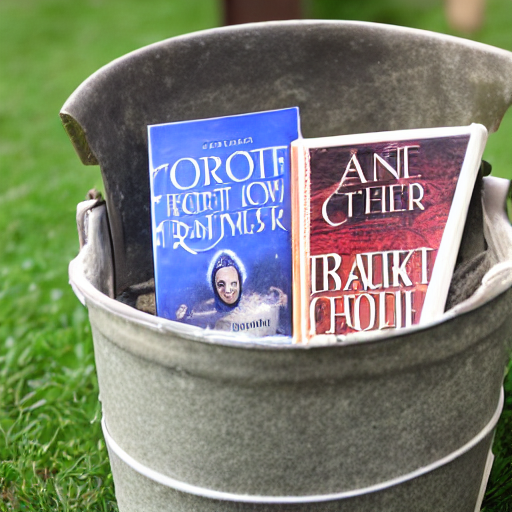

In [12]:
from diffusers import StableDiffusionPipeline
import torch

model_path = "runwayml/stable-diffusion-v1-5"
lora_path = args.output_dir

# Load Pipeline
pipe = StableDiffusionPipeline.from_pretrained(model_path, torch_dtype=torch.float16)
pipe.load_lora_weights(lora_path)
pipe.to("cuda")

# STUDENT EXPERIMENT: Change these values to generate 5 different samples
prompt = "a photo of a fantasy book in a bucket"
image = pipe(prompt, num_inference_steps=50, guidance_scale=5.0).images[0]
image.save("result_1.png")
image


  0%|          | 0/50 [00:00<?, ?it/s]

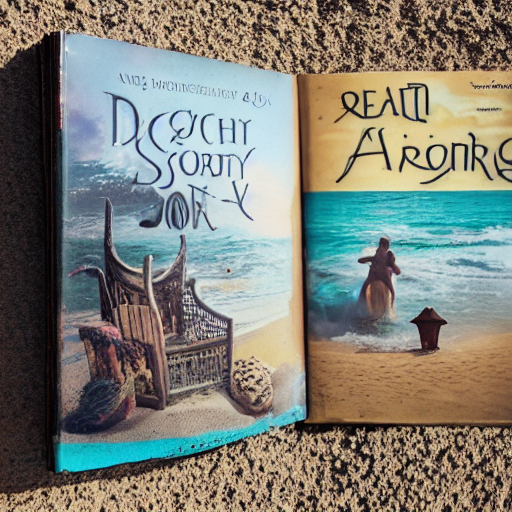

In [13]:
prompt = "a photo of a fantasy book at the beach"
image = pipe(prompt, num_inference_steps=50, guidance_scale=5.0).images[0]
image.save("result_2.png")
image

  0%|          | 0/50 [00:00<?, ?it/s]

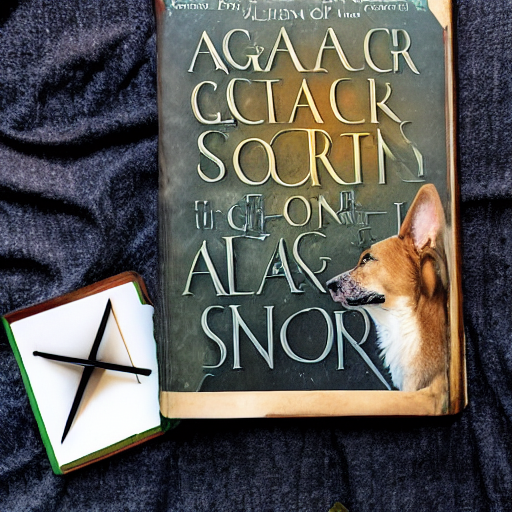

In [14]:
prompt = "a photo of a fantasy book in the mouth of a dog"
image = pipe(prompt, num_inference_steps=50, guidance_scale=5.0).images[0]
image.save("result_3.png")
image

  0%|          | 0/50 [00:00<?, ?it/s]

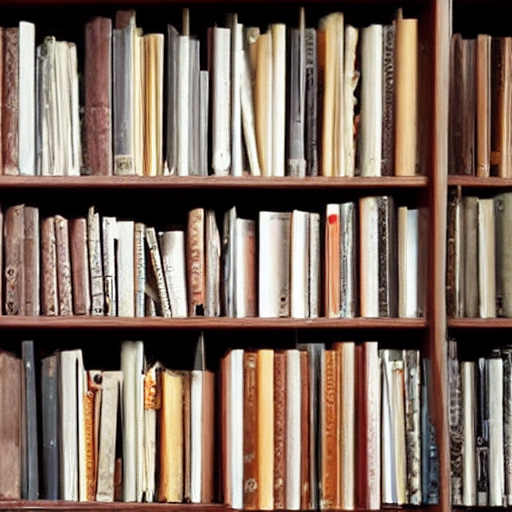

In [15]:
prompt = "a photo of a fantasy book in a shelf"
image = pipe(prompt, num_inference_steps=50, guidance_scale=5.0).images[0]
image.save("result_4.png")
image

  0%|          | 0/50 [00:00<?, ?it/s]

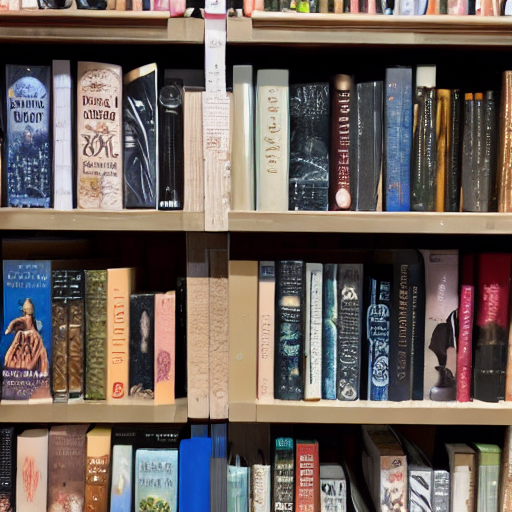

In [16]:
prompt = "a photo of a fantasy book in a bookstore"
image = pipe(prompt, num_inference_steps=50, guidance_scale=5.0).images[0]
image.save("result_5.png")
image